<a href="https://colab.research.google.com/github/VedanshiTare/ML-stock-backtester/blob/main/stock_backtester.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
!pip install -q yfinance xgboost shap scikit-learn seaborn matplotlib

In [34]:
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

portfolio = [
    "ITC.NS","COALINDIA.NS","RELIANCE.NS","INFY.NS","HDFCBANK.NS",
    "TCS.NS","ICICIBANK.NS","LT.NS","SBIN.NS","BHARTIARTL.NS"
]

In [35]:
def create_features(df):

    df = df.copy()
    df["Return"] = df["Close"].pct_change()


    df["SMA_10"] = df["Close"].rolling(10).mean()
    df["SMA_20"] = df["Close"].rolling(20).mean()
    df["SMA_50"] = df["Close"].rolling(50).mean()


    df["Momentum_5"] = df["Close"] - df["Close"].shift(5)
    df["Momentum_10"] = df["Close"] - df["Close"].shift(10)

    df["Vol_10"] = df["Return"].rolling(10).std()
    df["Vol_30"] = df["Return"].rolling(30).std()

    delta = df["Close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()

    rs = gain / (loss + 1e-10)
    df["RSI"] = 100 - (100 / (1 + rs))


    ema12 = df["Close"].ewm(span=12).mean()
    ema26 = df["Close"].ewm(span=26).mean()
    df["MACD"] = ema12 - ema26
    df["MACD_Signal"] = df["MACD"].ewm(span=9).mean()


    df["Volume_Change"] = df["Volume"].pct_change().replace([np.inf, -np.inf], np.nan)
    df["Volume_SMA"] = df["Volume"].rolling(10).mean()
    df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)


    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()

    return df

In [36]:
def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=2000),
        "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE
        )
    }

In [37]:
def evaluate_model(model, X, y):

    X = X.replace([np.inf, -np.inf], np.nan)
    y = y.copy()

    tscv = TimeSeriesSplit(n_splits=5)
    results = []

    for train_idx, test_idx in tscv.split(X):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


        train_mask = X_train.notna().all(axis=1)
        test_mask = X_test.notna().all(axis=1)

        X_train, y_train = X_train[train_mask], y_train[train_mask]
        X_test, y_test = X_test[test_mask], y_test[test_mask]

        if len(X_train) < 50 or len(X_test) < 20:
            continue

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test)[:, 1]
        else:
            probs = preds

        try:
            roc = roc_auc_score(y_test, probs)
        except:
            roc = np.nan

        results.append([
            accuracy_score(y_test, preds),
            precision_score(y_test, preds, zero_division=0),
            recall_score(y_test, preds, zero_division=0),
            f1_score(y_test, preds, zero_division=0),
            roc
        ])

    if len(results) == 0:
        return dict(zip(["Accuracy","Precision","Recall","F1","ROC_AUC"], [np.nan]*5))

    return dict(zip(
        ["Accuracy","Precision","Recall","F1","ROC_AUC"],
        np.nanmean(results, axis=0)
    ))

In [38]:
FEATURES = [
    "Close","Return","SMA_10","SMA_20","SMA_50",
    "Momentum_5","Momentum_10",
    "Vol_10","Vol_30",
    "RSI","MACD","MACD_Signal",
    "Volume_Change","Volume_SMA"
]

def analyze_stock(ticker):

    df = yf.download(ticker, start="2021-01-01", end="2026-06-01", progress=False)

    if df.empty:
        return None

    df = create_features(df)

    X = df[FEATURES]
    y = df["Target"]

    models = get_models()

    results = []

    for name, model in models.items():
        scores = evaluate_model(model, X, y)
        scores["Model"] = name
        results.append(scores)

    return df, pd.DataFrame(results)

In [39]:
portfolio_results = []
stock_data = {}

print("Running Portfolio Analysis...\n")

for ticker in portfolio:

    print("Analyzing", ticker)

    res = analyze_stock(ticker)

    if res is None:
        continue

    df_stock, metrics = res

    if metrics is None or metrics.empty:
        continue

    stock_data[ticker] = df_stock
    metrics["Ticker"] = ticker.replace(".NS","")

    portfolio_results.append(metrics)

all_results = pd.concat(portfolio_results, ignore_index=True)

print("Done")
all_results.head()

Running Portfolio Analysis...

Analyzing ITC.NS
Analyzing COALINDIA.NS
Analyzing RELIANCE.NS
Analyzing INFY.NS
Analyzing HDFCBANK.NS
Analyzing TCS.NS
Analyzing ICICIBANK.NS
Analyzing LT.NS
Analyzing SBIN.NS
Analyzing BHARTIARTL.NS
Done


,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Ticker
0,0.486916,0.494073,0.711692,0.550692,0.482537,Logistic Regression,ITC
1,0.497196,0.549050,0.363085,0.365700,0.517984,Random Forest,ITC
2,0.506542,0.540362,0.391093,0.420256,0.543591,XGBoost,ITC
3,0.545794,0.561568,0.841808,0.641963,0.511725,Logistic Regression,COALINDIA
4,0.512150,0.564682,0.554469,0.470352,0.526336,Random Forest,COALINDIA


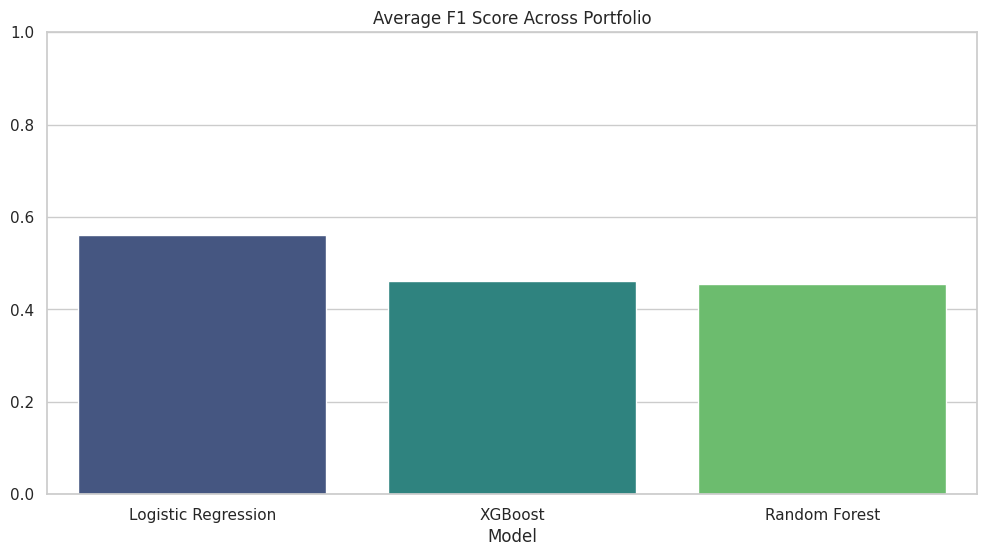

In [40]:
plt.figure(figsize=(12,6))

avg = all_results.groupby("Model")["F1"].mean().sort_values(ascending=False)

sns.barplot(x=avg.index, y=avg.values, palette="viridis")

plt.title("Average F1 Score Across Portfolio")
plt.ylim(0,1)
plt.show()

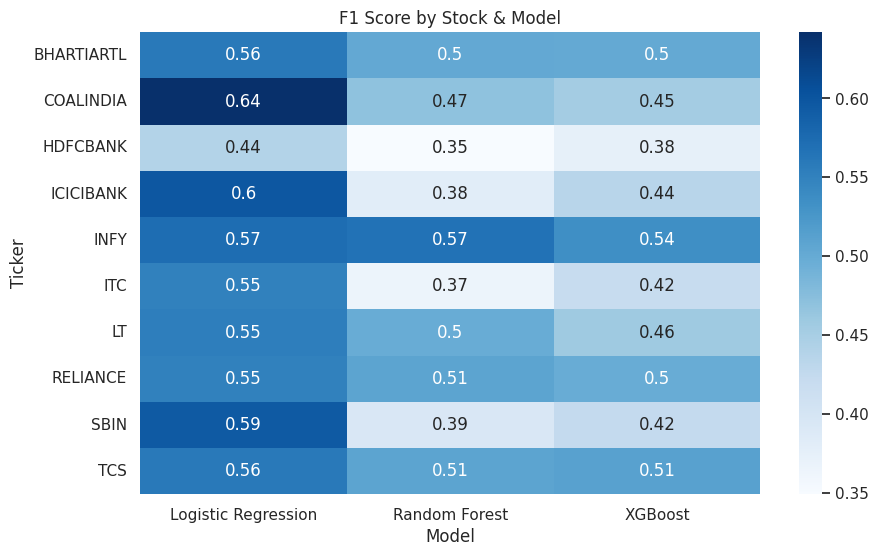

In [41]:
pivot = all_results.pivot_table(index="Ticker", columns="Model", values="F1")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="Blues")
plt.title("F1 Score by Stock & Model")
plt.show()

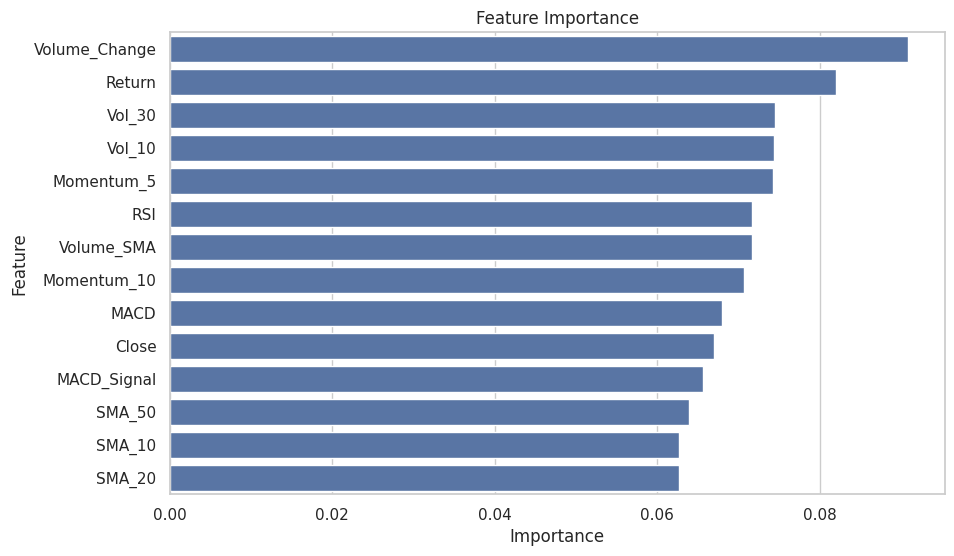

In [42]:
ticker = portfolio[0]
df = stock_data[ticker]

X = df[FEATURES]
y = df["Target"]

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)

imp = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=imp, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()

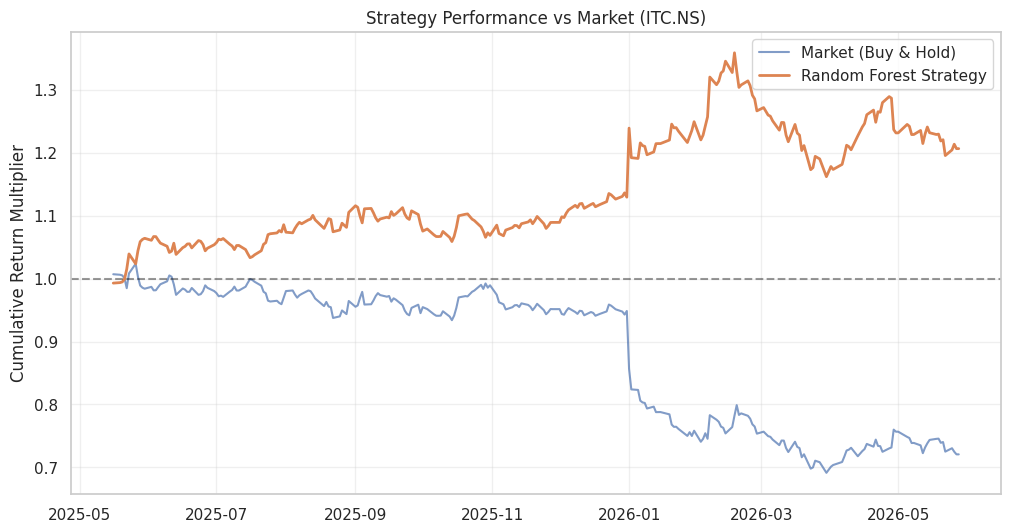

------------------------------
Total Market Return:   -27.93%
Total Strategy Return:  20.67%
------------------------------


In [43]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


eval_df = pd.DataFrame(index=X_test.index)
eval_df["Close"] = test["Close"]
eval_df["Probability"] = probs


eval_df["Position"] = np.where(eval_df["Probability"] > 0.5, 1, -1)


eval_df["Market_Return"] = eval_df["Close"].pct_change()

eval_df["Strategy_Return"] = eval_df["Position"].shift(1) * eval_df["Market_Return"]


eval_df = eval_df.dropna()


eval_df["Market_Equity"] = (1 + eval_df["Market_Return"]).cumprod()
eval_df["Strategy_Equity"] = (1 + eval_df["Strategy_Return"]).cumprod()


plt.figure(figsize=(12, 6))
plt.plot(eval_df.index, eval_df["Market_Equity"], label="Market (Buy & Hold)", alpha=0.7)
plt.plot(eval_df.index, eval_df["Strategy_Equity"], label="Random Forest Strategy", linewidth=2)


plt.axhline(1.0, color='black', linestyle='--', alpha=0.4)

plt.title(f"Strategy Performance vs Market ({ticker})")
plt.ylabel("Cumulative Return Multiplier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


strat_return = (eval_df["Strategy_Equity"].iloc[-1] - 1) * 100
market_return = (eval_df["Market_Equity"].iloc[-1] - 1) * 100

print("-" * 30)
print(f"Total Market Return:   {market_return:>6.2f}%")
print(f"Total Strategy Return: {strat_return:>6.2f}%")
print("-" * 30)

In [44]:
summary = all_results.groupby("Model")[["Accuracy","Precision","Recall","F1","ROC_AUC"]].mean()

summary

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.504766,0.515116,0.682415,0.562179,0.508364
Random Forest,0.504860,0.545485,0.499289,0.454705,0.521632
XGBoost,0.505794,0.541843,0.473538,0.461482,0.524453
